# Імпорт бібліотек

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from surprise import Dataset
from surprise import SVD
from surprise import SVDpp
from surprise import NMF

from surprise.model_selection import GridSearchCV
from surprise.model_selection import cross_validate

# Завантаження датасету MovieLens

In [2]:
data = Dataset.load_builtin('ml-100k')

# Модель SVD
# Пошук найкращих параметрів

In [3]:
svd_params = {
    'n_factors': [50, 100, 150],
    'n_epochs': [20, 30],
    'lr_all': [0.002, 0.005],
    'reg_all': [0.02, 0.05]
}

grid_svd = GridSearchCV(
    SVD,
    svd_params,
    measures=['rmse'],
    cv=3,
    n_jobs=-1
)

grid_svd.fit(data)

print("===== SVD =====")

print("Найкращий RMSE:")
print(grid_svd.best_score['rmse'])

print("\nНайкращі параметри:")
print(grid_svd.best_params['rmse'])

===== SVD =====
Найкращий RMSE:
0.9305073684862065

Найкращі параметри:
{'n_factors': 50, 'n_epochs': 30, 'lr_all': 0.005, 'reg_all': 0.05}


# Перевірка найкращого SVD

In [4]:
best_svd = grid_svd.best_estimator['rmse']

svd_result = cross_validate(
    best_svd,
    data,
    measures=['RMSE','MAE'],
    cv=5,
    verbose=True
)

Evaluating RMSE, MAE of algorithm SVD on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.9204  0.9172  0.9286  0.9233  0.9206  0.9220  0.0038  
MAE (testset)     0.7270  0.7230  0.7323  0.7295  0.7247  0.7273  0.0033  
Fit time          1.88    1.88    1.88    1.90    1.90    1.89    0.01    
Test time         0.26    0.18    0.27    0.18    0.20    0.22    0.04    


# Модель SVD++

In [5]:
svdpp_params = {
    'n_factors':[50,100],
    'n_epochs':[20],
    'lr_all':[0.005],
    'reg_all':[0.02]
}

grid_svdpp = GridSearchCV(
    SVDpp,
    svdpp_params,
    measures=['rmse'],
    cv=2,
    n_jobs=-1
)

grid_svdpp.fit(data)

print("\n===== SVD++ =====")

print("Найкращий RMSE:")
print(grid_svdpp.best_score['rmse'])

print("\nНайкращі параметри:")
print(grid_svdpp.best_params['rmse'])


===== SVD++ =====
Найкращий RMSE:
0.941905057610106

Найкращі параметри:
{'n_factors': 50, 'n_epochs': 20, 'lr_all': 0.005, 'reg_all': 0.02}


# Перевірка найкращого SVD++

In [6]:
best_svdpp = grid_svdpp.best_estimator['rmse']

svdpp_result = cross_validate(
    best_svdpp,
    data,
    measures=['RMSE','MAE'],
    cv=5,
    verbose=True
)

Evaluating RMSE, MAE of algorithm SVDpp on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.9209  0.9100  0.9200  0.9173  0.9289  0.9194  0.0061  
MAE (testset)     0.7242  0.7158  0.7241  0.7215  0.7293  0.7230  0.0044  
Fit time          76.04   76.88   77.26   77.28   76.69   76.83   0.45    
Test time         5.98    6.12    5.99    6.07    6.00    6.03    0.06    


# Модель NMF

In [7]:
nmf_params = {
    'n_factors':[15,30],
    'n_epochs':[20,50],
    'reg_pu':[0.02],
    'reg_qi':[0.02]
}

grid_nmf = GridSearchCV(
    NMF,
    nmf_params,
    measures=['rmse'],
    cv=3,
    n_jobs=-1
)

grid_nmf.fit(data)

print("\n===== NMF =====")

print("Найкращий RMSE:")
print(grid_nmf.best_score['rmse'])

print("\nНайкращі параметри:")
print(grid_nmf.best_params['rmse'])


===== NMF =====
Найкращий RMSE:
1.0237569103712827

Найкращі параметри:
{'n_factors': 15, 'n_epochs': 50, 'reg_pu': 0.02, 'reg_qi': 0.02}


# Перевірка найкращого NMF

In [8]:
best_nmf = grid_nmf.best_estimator['rmse']

nmf_result = cross_validate(
    best_nmf,
    data,
    measures=['RMSE','MAE'],
    cv=5,
    verbose=True
)

Evaluating RMSE, MAE of algorithm NMF on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    1.0188  1.0119  1.0022  1.0110  1.0122  1.0112  0.0053  
MAE (testset)     0.7818  0.7824  0.7728  0.7821  0.7767  0.7792  0.0038  
Fit time          2.85    2.85    2.81    2.87    2.82    2.84    0.02    
Test time         0.27    0.17    0.26    0.18    0.27    0.23    0.05    


# Порівняння моделей

In [9]:
comparison = pd.DataFrame({
    "Model":[
        "SVD",
        "SVD++",
        "NMF"
    ],
    "RMSE":[
        grid_svd.best_score['rmse'],
        grid_svdpp.best_score['rmse'],
        grid_nmf.best_score['rmse']
    ]
})

print("\n===== Порівняння моделей =====")
print(comparison)


===== Порівняння моделей =====
   Model      RMSE
0    SVD  0.930507
1  SVD++  0.941905
2    NMF  1.023757


# Графік порівняння

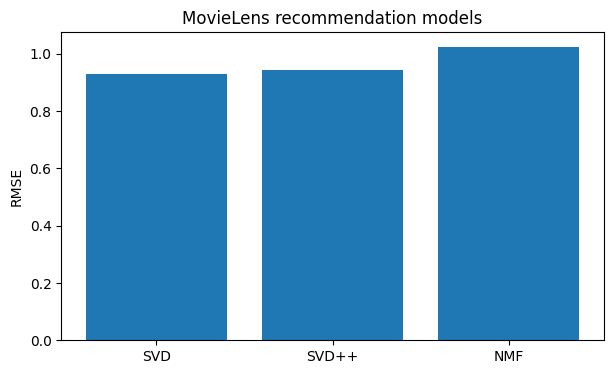

In [10]:
plt.figure(figsize=(7,4))
plt.bar(
    comparison["Model"],
    comparison["RMSE"]
)
plt.ylabel("RMSE")
plt.title(
    "MovieLens recommendation models"
)
plt.show()

# Найкраща модель

In [11]:
best_model = comparison.loc[
    comparison["RMSE"].idxmin()
]

print("\n===== Найкраща модель =====")
print(best_model)


===== Найкраща модель =====
Model         SVD
RMSE     0.930507
Name: 0, dtype: object


За результатами експерименту було порівняно три алгоритми рекомендаційних систем:
SVD, SVD++ та NMF. Оцінювання моделей виконувалось за метрикою RMSE. Оскільки менше значення RMSE означає кращу якість прогнозування, найкращою 
моделлю виявилась модель SVD із значенням RMSE 0.930507. Отже, для побудови рекомендаційної системи було обрано модель SVD.